Mounted at /content/drive
If you haven't downloaded 'kaggle.json' from your Kaggle account, do that now.
Use the file-upload dialog to upload 'kaggle.json'.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rishianand/devanagari-character-set
License(s): CC0-1.0
 62% 73.0M/118M [00:00<00:00, 708MB/s]
100% 118M/118M [00:00<00:00, 758MB/s] 

Top-level files/folders in /content/data:
- data.csv
- Images
/content/data/Images: 92000 files (sample subfolders: [PosixPath('/content/data/Images/Images')])


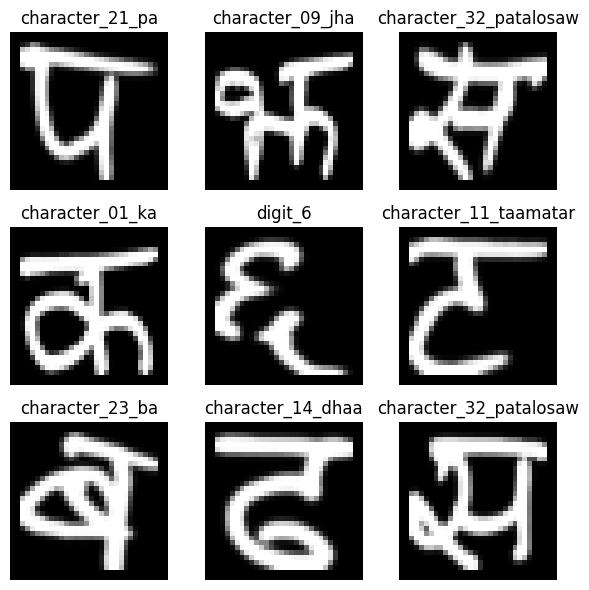


DONE: Dataset download + quick inspect. If you see images above and folders like class-names, we're good.


In [ ]:
# === Step 1: Download Devanagari Character Set into Colab ===
# Run in Google Colab (set Runtime -> Change runtime type -> GPU)

# 1) Mount Drive (optional but recommended)
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# 2) Install kaggle client
!pip install -q kaggle

# 3) Upload kaggle.json (you must download this from Kaggle: Account -> Create API token)
from google.colab import files
print("If you haven't downloaded 'kaggle.json' from your Kaggle account, do that now.")
print("Use the file-upload dialog to upload 'kaggle.json'.")
uploaded = files.upload()  # choose the kaggle.json file here

# 4) move to ~/.kaggle and set permissions
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open('kaggle.json','wb') as f:
  f.write(uploaded[list(uploaded.keys())[0]])
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 5) Download the dataset (chosen: rishianand/devanagari-character-set) into /content/data and unzip
!mkdir -p /content/data
!kaggle datasets download -d rishianand/devanagari-character-set -p /content/data --unzip

# 6) Quick inspect: list top-level and counts
import os
from pathlib import Path
DATA_ROOT = Path('/content/data')
print("\nTop-level files/folders in /content/data:")
for e in DATA_ROOT.iterdir():
    print("-", e.name)

# try to find the dataset folder automatically (some Kaggle zips have slightly different subfolder names)
possible_dirs = [p for p in DATA_ROOT.iterdir() if p.is_dir()]
if not possible_dirs:
    print("No directories found in /content/data — check the downloaded zip contents.")
else:
    # show counts for first few directories
    for p in possible_dirs[:6]:
        file_count = sum(1 for _ in p.rglob('*') if _.is_file())
        print(f"{p}: {file_count} files (sample subfolders: {list(p.iterdir())[:6]})")

# 7) Collect a few sample image paths and display them
from PIL import Image
import matplotlib.pyplot as plt
import random

# gather image files (png/jpg)
img_files = []
for root, dirs, files in os.walk('/content/data'):
    for fn in files:
        if fn.lower().endswith(('.png','.jpg','.jpeg')):
            img_files.append(os.path.join(root, fn))

if len(img_files) == 0:
    print("\nNo image files found yet — inspect the downloaded folder above for where images are stored.")
else:
    sample = random.sample(img_files, min(9, len(img_files)))
    plt.figure(figsize=(6,6))
    for i, imgp in enumerate(sample):
        plt.subplot(3,3,i+1)
        im = Image.open(imgp).convert('L')
        plt.imshow(im, cmap='gray')
        plt.title(os.path.basename(os.path.dirname(imgp)))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\nDONE: Dataset download + quick inspect. If you see images above and folders like class-names, we're good.")


Shape of dataset: (92000, 1025)
Columns: Index(['pixel_0000', 'pixel_0001', 'pixel_0002', 'pixel_0003', 'pixel_0004',
       'pixel_0005', 'pixel_0006', 'pixel_0007', 'pixel_0008', 'pixel_0009'],
      dtype='object') ...

Sample rows:
   pixel_0000  pixel_0001  pixel_0002  pixel_0003  pixel_0004  pixel_0005  \
0           0           0           0           0           0           0   
1           0           0           0           0           0           0   
2           0           0           0           0           0           0   
3           0           0           0           0           0           0   
4           0           0           0           0           0           0   

   pixel_0006  pixel_0007  pixel_0008  pixel_0009  ...  pixel_1015  \
0           0           0           0           0  ...           0   
1           0           0           0           0  ...           0   
2           0           0           0           0  ...           0   
3           0        

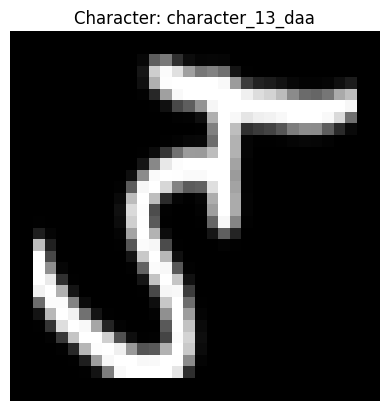

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your dataset CSV (update if filename differs)
DATASET_PATH = "/content/data/data.csv"

# Load dataset
df = pd.read_csv(DATASET_PATH)

# Show basic info
print("Shape of dataset:", df.shape)  # Expected: (92000, 1025)
print("Columns:", df.columns[:10], "...")  # First few column names
print("\nSample rows:")
print(df.head())

# Pick one random row
sample = df.sample(1).iloc[0]

# First column is label
label = sample["character"]

# Remaining 1024 columns are pixel values
pixels = sample.drop("character").values.astype(np.uint8)

# Reshape to 32x32 image
image = pixels.reshape(32, 32)

# Plot
plt.imshow(image, cmap="gray")
plt.title(f"Character: {label}")
plt.axis("off")
plt.show()


In [ ]:
# Step 3: Explore & Preprocess the Devanagari Dataset

# ----------------------------
# 1. Imports
# ----------------------------
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# ----------------------------
# 2. Load Dataset
# ----------------------------
DATASET_PATH = '/content/data/data.csv'  # update path
df = pd.read_csv(DATASET_PATH)

# ----------------------------
# 3. Explore Dataset
# ----------------------------
print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

print("\nClass distribution:")
print(df['character'].value_counts())

# ----------------------------
# 4. Separate Features & Labels
# ----------------------------
X = df.drop('character', axis=1).values  # pixel values
y = df['character'].values               # character labels

# ----------------------------
# 5. Normalize Pixel Values
# ----------------------------
X = X / 255.0  # scale pixels to 0-1

# ----------------------------
# 6. Reshape Features for CNN
# ----------------------------
X = X.reshape(-1, 32, 32, 1)  # 32x32 images with 1 channel

# ----------------------------
# 7. Encode Labels
# ----------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# ----------------------------
# 8. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of classes:", y_categorical.shape[1])


First 5 rows:
   pixel_0000  pixel_0001  pixel_0002  pixel_0003  pixel_0004  pixel_0005  \
0           0           0           0           0           0           0   
1           0           0           0           0           0           0   
2           0           0           0           0           0           0   
3           0           0           0           0           0           0   
4           0           0           0           0           0           0   

   pixel_0006  pixel_0007  pixel_0008  pixel_0009  ...  pixel_1015  \
0           0           0           0           0  ...           0   
1           0           0           0           0  ...           0   
2           0           0           0           0  ...           0   
3           0           0           0           0  ...           0   
4           0           0           0           0  ...           0   

   pixel_1016  pixel_1017  pixel_1018  pixel_1019  pixel_1020  pixel_1021  \
0           0           0

In [ ]:
# ----------------------------
# 1. Imports
# ----------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ----------------------------
# 2. Define CNN Model
# ----------------------------
num_classes = y_categorical.shape[1]  # number of unique characters

model = Sequential([
    # Convolutional Layer 1
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,1)),
    MaxPooling2D((2,2)),

    # Convolutional Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Convolutional Layer 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Flatten and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # output layer
])

# ----------------------------
# 3. Compile the Model
# ----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ----------------------------
# 4. Callbacks (Optional)
# ----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

# ----------------------------
# 5. Train the Model
# ----------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop, checkpoint]
)

# ----------------------------
# 6. Evaluate the Model
# ----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,270 (641.68 KB)

 Trainable params: 164,270 (641.68 KB)

...

460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9646 - loss: 0.1091 - val_accuracy: 0.9783 - val_loss: 0.0716
Epoch 11/30
453/460 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9673 - loss: 0.1016

460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9673 - loss: 0.1016 - val_accuracy: 0.9796 - val_loss: 0.0679
Epoch 12/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9692 - loss: 0.0956 - val_accuracy: 0.9789 - val_loss: 0.0721
Epoch 13/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9710 - loss: 0.0869 - val_accuracy: 0.9799 - val_loss: 0.0710
Epoch 14/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9731 - loss: 0.0811 - val_accuracy: 0.9794 - val_loss: 0.0714
Epoch 15/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9772 - loss: 0.0697 - val_accuracy: 0.9796 - val_loss: 0.0722
Epoch 16/30
459/460 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9771 - loss: 0.0691

460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9771 - loss: 0.0691 - val_accuracy: 0.9823 - val_loss: 0.0659
Epoch 17/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9783 - loss: 0.0641 - val_accuracy: 0.9807 - val_loss: 0.0673
Epoch 18/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9809 - loss: 0.0556 - val_accuracy: 0.9801 - val_loss: 0.0735
Epoch 19/30
456/460 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9818 - loss: 0.0537

460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9818 - loss: 0.0538 - val_accuracy: 0.9834 - val_loss: 0.0653
Epoch 20/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9820 - loss: 0.0528 - val_accuracy: 0.9829 - val_loss: 0.0661
Epoch 21/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9842 - loss: 0.0487 - val_accuracy: 0.9817 - val_loss: 0.0688
Epoch 22/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9824 - loss: 0.0522 - val_accuracy: 0.9825 - val_loss: 0.0674
Epoch 23/30
457/460 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9842 - loss: 0.0467

460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9842 - loss: 0.0467 - val_accuracy: 0.9850 - val_loss: 0.0612
Epoch 24/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9871 - loss: 0.0389 - val_accuracy: 0.9840 - val_loss: 0.0644
Epoch 25/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9863 - loss: 0.0404 - val_accuracy: 0.9827 - val_loss: 0.0674
Epoch 26/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9877 - loss: 0.0363 - val_accuracy: 0.9846 - val_loss: 0.0649
Epoch 27/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9875 - loss: 0.0376 - val_accuracy: 0.9838 - val_loss: 0.0694
Epoch 28/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9877 - loss: 0.0355 - val_accuracy: 0.9834 - val_loss: 0.0764
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9836 - loss: 0.0575

Test Accuracy: 98.30%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step


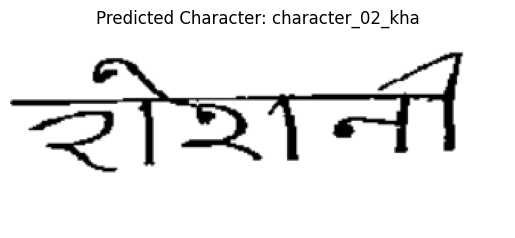

Predicted Character: character_02_kha
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0575

Test Accuracy on Dataset: 98.30%


In [ ]:
# ----------------------------
# Step 5: Test & Predict on Custom Image
# ----------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to preprocess the custom image
def preprocess_custom_image(img_path):
    # Load in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Resize to 32x32
    img = cv2.resize(img, (32, 32))

    # Invert colors (white text on black background)
    img = 255 - img

    # Normalize pixels
    img = img / 255.0

    # Reshape for CNN input
    img = img.reshape(1, 32, 32, 1)

    return img

# Function to predict character
def predict_character(img_path, model, label_encoder):
    img = preprocess_custom_image(img_path)

    # Predict
    pred = model.predict(img)
    class_index = np.argmax(pred)
    predicted_char = label_encoder.inverse_transform([class_index])[0]

    # Display image with prediction
    plt.imshow(cv2.imread(img_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
    plt.title(f"Predicted Character: {predicted_char}")
    plt.axis('off')
    plt.show()

    return predicted_char

# ----------------------------
# Use your Screenshot.png image
# ----------------------------
custom_img_path = '/content/Screenshot.png'
predicted_char = predict_character(custom_img_path, model, le)
print("Predicted Character:", predicted_char)

# Optional: Evaluate CNN on test dataset
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy on Dataset: {test_acc*100:.2f}%")


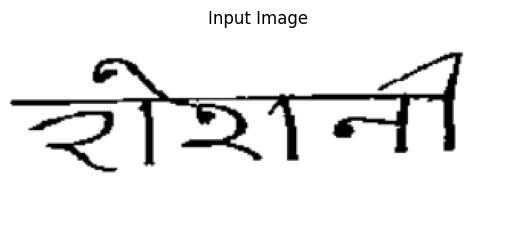

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted Text: character_02_khacharacter_02_kha


In [ ]:
# ----------------------------
# Step 6: Predict Full Word/Sentence
# ----------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Preprocess Character Image
# ----------------------------
def preprocess_char(img):
    """
    Preprocess single character image for CNN
    """
    img = cv2.resize(img, (32, 32))
    img = 255 - img  # invert colors
    img = img / 255.0
    img = img.reshape(1, 32, 32, 1)
    return img

# ----------------------------
# 2. Segment Image into Characters
# ----------------------------
def segment_characters(img_path):
    """
    Segment the input image into individual character images
    """
    # Load in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Threshold to binary image
    _, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)

    # Find contours of characters
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort contours left-to-right
    bounding_boxes = [cv2.boundingRect(c) for c in contours]
    bounding_boxes = sorted(bounding_boxes, key=lambda b: b[0])

    chars = []
    for x, y, w, h in bounding_boxes:
        char_img = thresh[y:y+h, x:x+w]
        chars.append(char_img)

    return chars, img

# ----------------------------
# 3. Predict Characters
# ----------------------------
def predict_word(img_path, model, label_encoder):
    chars, original_img = segment_characters(img_path)
    predicted_word = ""

    plt.imshow(original_img, cmap='gray')
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    for i, char_img in enumerate(chars):
        processed = preprocess_char(char_img)
        pred = model.predict(processed)
        class_index = np.argmax(pred)
        predicted_char = label_encoder.inverse_transform([class_index])[0]
        predicted_word += predicted_char

    return predicted_word

# ----------------------------
# 4. Test on Screenshot
# ----------------------------
custom_img_path = '/content/Screenshot.png'
predicted_text = predict_word(custom_img_path, model, le)
print("Predicted Text:", predicted_text)
